In [402]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from networkx.algorithms.shortest_paths import dense

In [403]:
df = pd.read_csv('data/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [404]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [405]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [406]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [407]:
df['Sex'] = df['Sex'].map({'male' : 0, 'female': 1})
df['Sex']

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    1
889    0
890    0
Name: Sex, Length: 891, dtype: int64

In [408]:
df.shape

(891, 12)

In [409]:
(df.isna().sum()/len(df))*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [410]:
cols = ['Age', 'Cabin', 'Embarked']
for col in cols:
    print((df[col].dtype))


float64
object
object


In [411]:
df['Cabin'].head()

0     NaN
1     C85
2     NaN
3    C123
4     NaN
Name: Cabin, dtype: object

In [412]:
df['Embarked'].head()

0    S
1    C
2    S
3    S
4    S
Name: Embarked, dtype: object

In [413]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Age'].isna()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Name: Age, Length: 891, dtype: bool

In [414]:
df.shape

(891, 12)

In [415]:
print(df['Cabin'].isna().sum()/len(df))
print(df['Cabin'].notna().sum()/len(df))

0.7710437710437711
0.22895622895622897


In [416]:
df['hasCabin'] = df['Cabin'].notna().astype(np.int64)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,hasCabin
0,1,0,3,"Braund, Mr. Owen Harris",0,22.000000,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.000000,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.000000,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",0,35.000000,0,0,373450,8.0500,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.000000,0,0,211536,13.0000,NaN,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.000000,0,0,112053,30.0000,B42,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,29.699118,1,2,W./C. 6607,23.4500,NaN,S,0
889,890,1,1,"Behr, Mr. Karl Howell",0,26.000000,0,0,111369,30.0000,C148,C,1


In [417]:
print(np.corrcoef(df['hasCabin'], df['Survived']))

[[1.         0.31691152]
 [0.31691152 1.        ]]


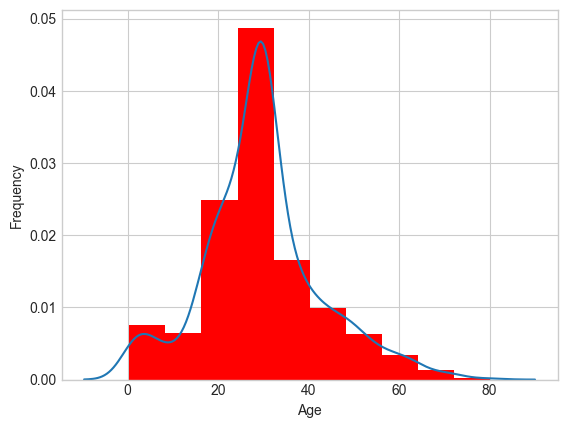

In [418]:
age = df['Age']
age.plot(kind ='hist', bins=10, color='red', density=True)
sns.kdeplot(age)
plt.show()


In [419]:
age.skew()

np.float64(0.4344880940129925)

In [420]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Age'] = scaler.fit_transform(df[['Age']])
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,hasCabin
0,1,0,3,"Braund, Mr. Owen Harris",0,-0.592481,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0.638789,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",1,-0.284663,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0.407926,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",0,0.407926,0,0,373450,8.0500,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,-0.207709,0,0,211536,13.0000,NaN,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",1,-0.823344,0,0,112053,30.0000,B42,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,0.000000,1,2,W./C. 6607,23.4500,NaN,S,0
889,890,1,1,"Behr, Mr. Karl Howell",0,-0.284663,0,0,111369,30.0000,C148,C,1


In [421]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,hasCabin
0,1,0,3,"Braund, Mr. Owen Harris",0,-0.592481,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0.638789,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",1,-0.284663,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0.407926,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",0,0.407926,0,0,373450,8.0500,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,-0.207709,0,0,211536,13.0000,NaN,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",1,-0.823344,0,0,112053,30.0000,B42,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,0.000000,1,2,W./C. 6607,23.4500,NaN,S,0
889,890,1,1,"Behr, Mr. Karl Howell",0,-0.284663,0,0,111369,30.0000,C148,C,1


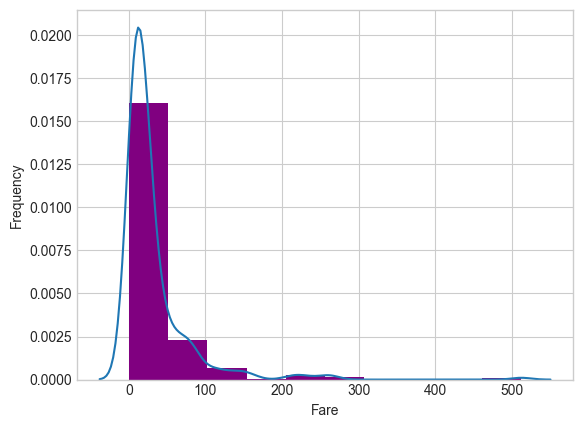

In [422]:
fare = df['Fare']
fare.plot(kind='hist', bins=10, color='purple', density='True')
sns.kdeplot(fare)
plt.show()

In [423]:
fare.skew()

np.float64(4.787316519674893)

In [424]:
q1 = np.quantile(fare, 0.25)
q3 = np.quantile(fare, 0.75)
iqr = q3-q1

lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr

outliers = fare[(fare < lower_bound) | (fare > upper_bound)]
outliers.count()

np.int64(116)

In [425]:
df['Fare'] = scaler.fit_transform(df[['Fare']])
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,hasCabin
0,1,0,3,"Braund, Mr. Owen Harris",0,-0.592481,1,0,A/5 21171,-0.502445,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0.638789,1,0,PC 17599,0.786845,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",1,-0.284663,0,0,STON/O2. 3101282,-0.488854,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0.407926,1,0,113803,0.420730,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",0,0.407926,0,0,373450,-0.486337,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,-0.207709,0,0,211536,-0.386671,NaN,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",1,-0.823344,0,0,112053,-0.044381,B42,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,0.000000,1,2,W./C. 6607,-0.176263,NaN,S,0
889,890,1,1,"Behr, Mr. Karl Howell",0,-0.284663,0,0,111369,-0.044381,C148,C,1


In [426]:
df['Embarked'].isna().sum()

np.int64(2)

In [427]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)

encode = ohe.fit_transform(df[['Embarked']])

In [428]:
encode_df = pd.DataFrame(encode, columns=ohe.get_feature_names_out())
encode_df

,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan
0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0
...,...,...,...,...
886,0.0,0.0,1.0,0.0
887,0.0,0.0,1.0,0.0
888,0.0,0.0,1.0,0.0
889,1.0,0.0,0.0,0.0


In [429]:
df = pd.concat([df.drop('Embarked', axis=1), encode_df], axis=1)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,hasCabin,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan
0,1,0,3,"Braund, Mr. Owen Harris",0,-0.592481,1,0,A/5 21171,-0.502445,NaN,0,0.0,0.0,1.0,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0.638789,1,0,PC 17599,0.786845,C85,1,1.0,0.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",1,-0.284663,0,0,STON/O2. 3101282,-0.488854,NaN,0,0.0,0.0,1.0,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0.407926,1,0,113803,0.420730,C123,1,0.0,0.0,1.0,0.0
4,5,0,3,"Allen, Mr. William Henry",0,0.407926,0,0,373450,-0.486337,NaN,0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,-0.207709,0,0,211536,-0.386671,NaN,0,0.0,0.0,1.0,0.0
887,888,1,1,"Graham, Miss. Margaret Edith",1,-0.823344,0,0,112053,-0.044381,B42,1,0.0,0.0,1.0,0.0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,0.000000,1,2,W./C. 6607,-0.176263,NaN,0,0.0,0.0,1.0,0.0
889,890,1,1,"Behr, Mr. Karl Howell",0,-0.284663,0,0,111369,-0.044381,C148,1,1.0,0.0,0.0,0.0


In [430]:
df.drop('Embarked_nan', axis=1, inplace=True)
cols = ['Embarked_C', 'Embarked_Q', 'Embarked_S']

for col in cols:
    df[col] = df[col].fillna(df[col].mean())
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,hasCabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,-0.592481,1,0,A/5 21171,-0.502445,NaN,0,0.0,0.0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0.638789,1,0,PC 17599,0.786845,C85,1,1.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",1,-0.284663,0,0,STON/O2. 3101282,-0.488854,NaN,0,0.0,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0.407926,1,0,113803,0.420730,C123,1,0.0,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",0,0.407926,0,0,373450,-0.486337,NaN,0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,-0.207709,0,0,211536,-0.386671,NaN,0,0.0,0.0,1.0
887,888,1,1,"Graham, Miss. Margaret Edith",1,-0.823344,0,0,112053,-0.044381,B42,1,0.0,0.0,1.0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,0.000000,1,2,W./C. 6607,-0.176263,NaN,0,0.0,0.0,1.0
889,890,1,1,"Behr, Mr. Karl Howell",0,-0.284663,0,0,111369,-0.044381,C148,1,1.0,0.0,0.0


In [431]:
df.drop_duplicates()
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,hasCabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,-0.592481,1,0,A/5 21171,-0.502445,NaN,0,0.0,0.0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0.638789,1,0,PC 17599,0.786845,C85,1,1.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",1,-0.284663,0,0,STON/O2. 3101282,-0.488854,NaN,0,0.0,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0.407926,1,0,113803,0.420730,C123,1,0.0,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",0,0.407926,0,0,373450,-0.486337,NaN,0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,-0.207709,0,0,211536,-0.386671,NaN,0,0.0,0.0,1.0
887,888,1,1,"Graham, Miss. Margaret Edith",1,-0.823344,0,0,112053,-0.044381,B42,1,0.0,0.0,1.0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,0.000000,1,2,W./C. 6607,-0.176263,NaN,0,0.0,0.0,1.0
889,890,1,1,"Behr, Mr. Karl Howell",0,-0.284663,0,0,111369,-0.044381,C148,1,1.0,0.0,0.0


In [432]:
df.to_csv('data/cleanedDataset.csv', index=False)